Initial check of the distribution of fields

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
SELECT
--EXTRACT(YEAR FROM date_received) AS year_received,
--CASE WHEN consumer_complaint_narrative is NULL Then 0 ELSE 1 END AS narritive_y_n,
--consumer_disputed,
--timely_response,
company_public_response,
company_response_to_consumer,
count(*) as count
FROM `msds-434-502817.cfpb_data.complaint_database`
WHERE company_public_response is not null
GROUP BY
--year_received,
company_public_response,
company_response_to_consumer
--narritive_y_n,
--consumer_disputed
--timely_response
ORDER BY
--year_received,
company_public_response,
company_response_to_consumer
--narritive_y_n,
--consumer_disputed
--timely_response
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

,company_public_response,company_response_to_consumer,count
0,Company believes complaint caused principally ...,Closed,88
1,Company believes complaint caused principally ...,Closed with explanation,6281
2,Company believes complaint caused principally ...,Closed with monetary relief,167
3,Company believes complaint caused principally ...,Closed with non-monetary relief,642
4,Company believes complaint is the result of an...,Closed,41
5,Company believes complaint is the result of an...,Closed with explanation,4254
6,Company believes complaint is the result of an...,Closed with monetary relief,643
7,Company believes complaint is the result of an...,Closed with non-monetary relief,799
8,Company believes complaint relates to a discon...,Closed,1
9,Company believes complaint relates to a discon...,Closed with explanation,72


Check distribution of monetary relief



In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
SELECT
  IF(
    company_response_to_consumer = 'Closed with monetary relief',
    1,
    0
  ) AS monetary_relief,

  COUNT(*) AS complaint_count,

  ROUND(
    100 * SAFE_DIVIDE(
      COUNT(*),
      SUM(COUNT(*)) OVER ()
    ),
    2
  ) AS percentage

FROM
  `msds-434-502817.cfpb_data.complaint_database`

WHERE
  company_response_to_consumer IS NOT NULL
  AND date_sent_to_company IS NOT NULL
  AND date_received BETWEEN
    DATE '2018-01-01' AND DATE '2022-12-31'

GROUP BY
  monetary_relief

ORDER BY
  monetary_relief;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

,monetary_relief,complaint_count,percentage
0,0,2208059,97.05
1,1,67220,2.95


Making the first Model

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
#standardSQL

CREATE OR REPLACE MODEL
  `msds-434-502817.cfpb_data.monetary_relief_model`

OPTIONS(
  model_type = 'LOGISTIC_REG',
  input_label_cols = ['monetary_relief'],
  auto_class_weights = TRUE
)

AS

SELECT
  IF(
    company_response_to_consumer = 'Closed with monetary relief',
    1,
    0
  ) AS monetary_relief,

  IFNULL(product, 'Unknown') AS product,
  IFNULL(subproduct, 'Unknown') AS subproduct,
  IFNULL(issue, 'Unknown') AS issue,
  IFNULL(subissue, 'Unknown') AS subissue,
  IFNULL(company_name, 'Unknown') AS company_name,
  IFNULL(state, 'Unknown') AS state,
  IFNULL(submitted_via, 'Unknown') AS submitted_via,
  IFNULL(consumer_consent_provided, 'Unknown')
    AS consumer_consent_provided,
  IFNULL(tags, 'No tag') AS consumer_tags,

  IF(
    consumer_complaint_narrative IS NULL
      OR TRIM(consumer_complaint_narrative) = '',
    0,
    1
  ) AS has_narrative,

  LENGTH(
    IFNULL(consumer_complaint_narrative, '')
  ) AS narrative_character_count,

  ARRAY_LENGTH(
    REGEXP_EXTRACT_ALL(
      IFNULL(consumer_complaint_narrative, ''),
      r'\b[\w]+\b'
    )
  ) AS narrative_word_count,

  EXTRACT(MONTH FROM date_received) AS month_received,

  DATE_DIFF(
    date_sent_to_company,
    date_received,
    DAY
  ) AS days_to_send_to_company

FROM
  `msds-434-502817.cfpb_data.complaint_database`

WHERE
  company_response_to_consumer IS NOT NULL
  AND date_sent_to_company IS NOT NULL
  AND date_received BETWEEN
    DATE '2018-01-01' AND DATE '2022-12-31';
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

<>:51: SyntaxWarning: invalid escape sequence '\w'
<>:51: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_4567/147110341.py:51: SyntaxWarning: invalid escape sequence '\w'
  r'\b[\w]+\b'


,statement_type,job_id,location
0,CREATE_MODEL,job_vCbSnYBimHmcnyTJOmqej81j4ajK,US


Evaluate first model

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
#standardSQL

SELECT
  *

FROM
  ML.EVALUATE(
    MODEL `msds-434-502817.cfpb_data.monetary_relief_model`,

    (
      SELECT
        IF(
          company_response_to_consumer = 'Closed with monetary relief',
          1,
          0
        ) AS monetary_relief,

        IFNULL(product, 'Unknown') AS product,
        IFNULL(subproduct, 'Unknown') AS subproduct,
        IFNULL(issue, 'Unknown') AS issue,
        IFNULL(subissue, 'Unknown') AS subissue,
        IFNULL(company_name, 'Unknown') AS company_name,
        IFNULL(state, 'Unknown') AS state,
        IFNULL(submitted_via, 'Unknown') AS submitted_via,

        IFNULL(
          consumer_consent_provided,
          'Unknown'
        ) AS consumer_consent_provided,

        IFNULL(tags, 'No tag') AS consumer_tags,

        IF(
          consumer_complaint_narrative IS NULL
            OR TRIM(consumer_complaint_narrative) = '',
          0,
          1
        ) AS has_narrative,

        LENGTH(
          IFNULL(consumer_complaint_narrative, '')
        ) AS narrative_character_count,

        ARRAY_LENGTH(
          REGEXP_EXTRACT_ALL(
            IFNULL(consumer_complaint_narrative, ''),
            r'\b[\w]+\b'
          )
        ) AS narrative_word_count,


        EXTRACT(
          MONTH FROM date_received
        ) AS month_received,

        DATE_DIFF(
          date_sent_to_company,
          date_received,
          DAY
        ) AS days_to_send_to_company

      FROM
        `msds-434-502817.cfpb_data.complaint_database`

      WHERE
        company_response_to_consumer IS NOT NULL
        AND date_sent_to_company IS NOT NULL
        AND date_received BETWEEN
          DATE '2023-01-01' AND DATE '2023-03-23'
    ),
    STRUCT(0.75 AS threshold)
  );
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

<>:52: SyntaxWarning: invalid escape sequence '\w'
<>:52: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_4567/1487493107.py:52: SyntaxWarning: invalid escape sequence '\w'
  r'\b[\w]+\b'


,precision,recall,accuracy,f1_score,log_loss,roc_auc
0,0.16407,0.733178,0.950894,0.268137,0.190565,0.963852


Create second model- this includes using specific words in the consumer narrative to help the prediction while also removing fields we determined unnecessary

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
#standardSQL

CREATE OR REPLACE MODEL
  `msds-434-502817.cfpb_data.monetary_relief_model_2`

OPTIONS(
  model_type = 'LOGISTIC_REG',
  input_label_cols = ['monetary_relief'],
  auto_class_weights = TRUE
)

AS

SELECT
  IF(
    company_response_to_consumer = 'Closed with monetary relief',
    1,
    0
  ) AS monetary_relief,

  IFNULL(product, 'Unknown') AS product,
  IFNULL(subproduct, 'Unknown') AS subproduct,
  IFNULL(issue, 'Unknown') AS issue,
  IFNULL(subissue, 'Unknown') AS subissue,
  IFNULL(company_name, 'Unknown') AS company_name,
  IFNULL(submitted_via, 'Unknown') AS submitted_via,

  IFNULL(
    consumer_consent_provided,
    'Unknown'
  ) AS consumer_consent_provided,

  IFNULL(tags, 'No tag') AS consumer_tags,

  IF(
    consumer_complaint_narrative IS NULL
      OR TRIM(consumer_complaint_narrative) = '',
    0,
    1
  ) AS has_narrative,

  ARRAY_LENGTH(
    REGEXP_EXTRACT_ALL(
      LOWER(
        IFNULL(consumer_complaint_narrative, '')
      ),
      r'\b[a-z]+\b'
    )
  ) AS narrative_word_count,

  IF(
    REGEXP_CONTAINS(
      LOWER(
        IFNULL(consumer_complaint_narrative, '')
      ),
      r'\bfee(s)?\b|\boverdraft(s)?\b|\boverdrawn\b|\bwaiv(e|ed|er)\b'
    ),
    1,
    0
  ) AS mentions_fees_or_overdraft,

  IF(
    REGEXP_CONTAINS(
      LOWER(
        IFNULL(consumer_complaint_narrative, '')
      ),
      r'\brefund(ed|ing|s)?\b|\brevers(e|ed|al)\b|\bcredit(ed)?\b|\breimburse(d|ment)?\b'
    ),
    1,
    0
  ) AS mentions_refund_or_credit,

  IF(
    REGEXP_CONTAINS(
      LOWER(
        IFNULL(consumer_complaint_narrative, '')
      ),
      r'\bunauthoriz(ed|ation)\b|\bfraud\b|\bscam\b|\bnot mine\b'
    ),
    1,
    0
  ) AS mentions_unauthorized_or_fraud,

  IF(
    REGEXP_CONTAINS(
      LOWER(
        IFNULL(consumer_complaint_narrative, '')
      ),
      r'\bcharge(d|s|ing)?\b|\bpurchase(s|d)?\b|\bmerchant\b|\btransaction(s)?\b'
    ),
    1,
    0
  ) AS mentions_charge_or_purchase,

  IF(
    REGEXP_CONTAINS(
      LOWER(
        IFNULL(consumer_complaint_narrative, '')
      ),
      r'\batm\b|\bdebit\b|\bwithdraw(al|als|n)?\b'
    ),
    1,
    0
  ) AS mentions_debit_or_withdrawal,

  IF(
    REGEXP_CONTAINS(
      LOWER(
        IFNULL(consumer_complaint_narrative, '')
      ),
      r'\bdeposit(ed|s)?\b|\bchecking\b|\bsavings\b|\bbranch\b|\bfunds\b'
    ),
    1,
    0
  ) AS mentions_deposit_account,

  IF(
    REGEXP_CONTAINS(
      LOWER(
        IFNULL(consumer_complaint_narrative, '')
      ),
      r'\binterest\b|\bpromot(ion|ional)\b|\bbonus\b|\badvertis(ed|ing|ement)?\b'
    ),
    1,
    0
  ) AS mentions_interest_or_promotion

FROM
  `msds-434-502817.cfpb_data.complaint_database`

WHERE
  company_response_to_consumer IS NOT NULL
  AND date_received BETWEEN
    DATE '2018-01-01' AND DATE '2022-12-31';
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

In [1]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
#standardSQL

SELECT
  *

FROM
  ML.EVALUATE(
    MODEL `msds-434-502817.cfpb_data.monetary_relief_model_2`,

    (
      SELECT
        IF(
          company_response_to_consumer = 'Closed with monetary relief',
          1,
          0
        ) AS monetary_relief,

        IFNULL(product, 'Unknown') AS product,
        IFNULL(subproduct, 'Unknown') AS subproduct,
        IFNULL(issue, 'Unknown') AS issue,
        IFNULL(subissue, 'Unknown') AS subissue,
        IFNULL(company_name, 'Unknown') AS company_name,
        IFNULL(submitted_via, 'Unknown') AS submitted_via,

        IFNULL(
          consumer_consent_provided,
          'Unknown'
        ) AS consumer_consent_provided,

        IFNULL(tags, 'No tag') AS consumer_tags,

        IF(
          consumer_complaint_narrative IS NULL
            OR TRIM(consumer_complaint_narrative) = '',
          0,
          1
        ) AS has_narrative,

        ARRAY_LENGTH(
          REGEXP_EXTRACT_ALL(
            LOWER(
              IFNULL(consumer_complaint_narrative, '')
            ),
            r'\b[a-z]+\b'
          )
        ) AS narrative_word_count,

        IF(
          REGEXP_CONTAINS(
            LOWER(
              IFNULL(consumer_complaint_narrative, '')
            ),
            r'\bfee(s)?\b|\boverdraft(s)?\b|\boverdrawn\b|\bwaiv(e|ed|er)\b'
          ),
          1,
          0
        ) AS mentions_fees_or_overdraft,

        IF(
          REGEXP_CONTAINS(
            LOWER(
              IFNULL(consumer_complaint_narrative, '')
            ),
            r'\brefund(ed|ing|s)?\b|\brevers(e|ed|al)\b|\bcredit(ed)?\b|\breimburse(d|ment)?\b'
          ),
          1,
          0
        ) AS mentions_refund_or_credit,

        IF(
          REGEXP_CONTAINS(
            LOWER(
              IFNULL(consumer_complaint_narrative, '')
            ),
            r'\bunauthoriz(ed|ation)\b|\bfraud\b|\bscam\b|\bnot mine\b'
          ),
          1,
          0
        ) AS mentions_unauthorized_or_fraud,

        IF(
          REGEXP_CONTAINS(
            LOWER(
              IFNULL(consumer_complaint_narrative, '')
            ),
            r'\bcharge(d|s|ing)?\b|\bpurchase(s|d)?\b|\bmerchant\b|\btransaction(s)?\b'
          ),
          1,
          0
        ) AS mentions_charge_or_purchase,

        IF(
          REGEXP_CONTAINS(
            LOWER(
              IFNULL(consumer_complaint_narrative, '')
            ),
            r'\batm\b|\bdebit\b|\bwithdraw(al|als|n)?\b'
          ),
          1,
          0
        ) AS mentions_debit_or_withdrawal,

        IF(
          REGEXP_CONTAINS(
            LOWER(
              IFNULL(consumer_complaint_narrative, '')
            ),
            r'\bdeposit(ed|s)?\b|\bchecking\b|\bsavings\b|\bbranch\b|\bfunds\b'
          ),
          1,
          0
        ) AS mentions_deposit_account,

        IF(
          REGEXP_CONTAINS(
            LOWER(
              IFNULL(consumer_complaint_narrative, '')
            ),
            r'\binterest\b|\bpromot(ion|ional)\b|\bbonus\b|\badvertis(ed|ing|ement)?\b'
          ),
          1,
          0
        ) AS mentions_interest_or_promotion

      FROM
        `msds-434-502817.cfpb_data.complaint_database`

      WHERE
        company_response_to_consumer IS NOT NULL
        AND date_received BETWEEN
          DATE '2023-01-01' AND DATE '2023-03-23'
    ),

    STRUCT(0.75 AS threshold)
  );
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

,precision,recall,accuracy,f1_score,log_loss,roc_auc
0,0.157374,0.752165,0.947547,0.260288,0.198872,0.963191


Model 3- remove text from search and also remove unnecessary fields

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
#standardSQL

CREATE OR REPLACE MODEL
  `msds-434-502817.cfpb_data.monetary_relief_model_3`

OPTIONS(
  model_type = 'LOGISTIC_REG',
  input_label_cols = ['monetary_relief'],
  auto_class_weights = TRUE
)

AS

SELECT
  IF(
    company_response_to_consumer = 'Closed with monetary relief',
    1,
    0
  ) AS monetary_relief,

  IFNULL(product, 'Unknown') AS product,
  IFNULL(subproduct, 'Unknown') AS subproduct,
  IFNULL(issue, 'Unknown') AS issue,
  IFNULL(subissue, 'Unknown') AS subissue,
  IFNULL(company_name, 'Unknown') AS company_name,
  IFNULL(submitted_via, 'Unknown') AS submitted_via,

  IFNULL(
    consumer_consent_provided,
    'Unknown'
  ) AS consumer_consent_provided,

  IFNULL(tags, 'No tag') AS consumer_tags,

  IF(
    consumer_complaint_narrative IS NULL
      OR TRIM(consumer_complaint_narrative) = '',
    0,
    1
  ) AS has_narrative,

  ARRAY_LENGTH(
    REGEXP_EXTRACT_ALL(
      LOWER(
        IFNULL(consumer_complaint_narrative, '')
      ),
      r'\b[a-z]+\b'
    )
  ) AS narrative_word_count

FROM
  `msds-434-502817.cfpb_data.complaint_database`

WHERE
  company_response_to_consumer IS NOT NULL
  AND date_received BETWEEN
    DATE '2018-01-01' AND DATE '2022-12-31';
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

In [2]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
#standardSQL

SELECT
  *

FROM
  ML.EVALUATE(
    MODEL `msds-434-502817.cfpb_data.monetary_relief_model_3`,

    (
      SELECT
        IF(
          company_response_to_consumer = 'Closed with monetary relief',
          1,
          0
        ) AS monetary_relief,

        IFNULL(product, 'Unknown') AS product,
        IFNULL(subproduct, 'Unknown') AS subproduct,
        IFNULL(issue, 'Unknown') AS issue,
        IFNULL(subissue, 'Unknown') AS subissue,
        IFNULL(company_name, 'Unknown') AS company_name,
        IFNULL(submitted_via, 'Unknown') AS submitted_via,

        IFNULL(
          consumer_consent_provided,
          'Unknown'
        ) AS consumer_consent_provided,

        IFNULL(tags, 'No tag') AS consumer_tags,

        IF(
          consumer_complaint_narrative IS NULL
            OR TRIM(consumer_complaint_narrative) = '',
          0,
          1
        ) AS has_narrative,

        ARRAY_LENGTH(
          REGEXP_EXTRACT_ALL(
            LOWER(
              IFNULL(consumer_complaint_narrative, '')
            ),
            r'\b[a-z]+\b'
          )
        ) AS narrative_word_count

      FROM
        `msds-434-502817.cfpb_data.complaint_database`

      WHERE
        company_response_to_consumer IS NOT NULL
        AND date_received BETWEEN
          DATE '2023-01-01' AND DATE '2023-03-23'
    ),

    STRUCT(0.75 AS threshold)
  );
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

,precision,recall,accuracy,f1_score,log_loss,roc_auc
0,0.157374,0.752165,0.947547,0.260288,0.198857,0.9632


Model one had the best results.

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
#standardSQL

SELECT
  complaint_id,
  predicted_monetary_relief,
  predicted_monetary_relief_probs,
  monetary_relief AS actual_monetary_relief,
  product,
  issue,
  company_name,
  submitted_via,
  narrative_character_count,
  narrative_word_count

FROM
  ML.PREDICT(
    MODEL `msds-434-502817.cfpb_data.monetary_relief_model`,

    (
      SELECT
        complaint_id,

        IF(
          company_response_to_consumer = 'Closed with monetary relief',
          1,
          0
        ) AS monetary_relief,

        IFNULL(product, 'Unknown') AS product,
        IFNULL(subproduct, 'Unknown') AS subproduct,
        IFNULL(issue, 'Unknown') AS issue,
        IFNULL(subissue, 'Unknown') AS subissue,
        IFNULL(company_name, 'Unknown') AS company_name,
        IFNULL(state, 'Unknown') AS state,
        IFNULL(submitted_via, 'Unknown') AS submitted_via,

        IFNULL(
          consumer_consent_provided,
          'Unknown'
        ) AS consumer_consent_provided,

        IFNULL(tags, 'No tag') AS consumer_tags,

        IF(
          consumer_complaint_narrative IS NULL
            OR TRIM(consumer_complaint_narrative) = '',
          0,
          1
        ) AS has_narrative,

        LENGTH(
          IFNULL(consumer_complaint_narrative, '')
        ) AS narrative_character_count,

        ARRAY_LENGTH(
          REGEXP_EXTRACT_ALL(
            IFNULL(consumer_complaint_narrative, ''),
            r'\b[\w]+\b'
          )
        ) AS narrative_word_count,


        EXTRACT(
          MONTH FROM date_received
        ) AS month_received,

        DATE_DIFF(
          date_sent_to_company,
          date_received,
          DAY
        ) AS days_to_send_to_company

      FROM
        `msds-434-502817.cfpb_data.complaint_database`

      WHERE
        company_response_to_consumer IS NOT NULL
        AND date_sent_to_company IS NOT NULL
        AND date_received BETWEEN
          DATE '2023-01-01' AND DATE '2023-03-23'
    ),

    STRUCT(0.75 AS threshold)
  )

ORDER BY
  predicted_monetary_relief DESC

LIMIT 100;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

Additional analysis that was done:

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
--Correlation between narrative metrics and monetary relief
#standardSQL

WITH complaint_features AS (
  SELECT
    IF(
      company_response_to_consumer = 'Closed with monetary relief',
      1,
      0
    ) AS monetary_relief,

    LENGTH(
      IFNULL(consumer_complaint_narrative, '')
    ) AS narrative_character_count,

    ARRAY_LENGTH(
      REGEXP_EXTRACT_ALL(
        LOWER(IFNULL(consumer_complaint_narrative, '')),
        r'\b[a-z]+\b'
      )
    ) AS narrative_word_count,

    DATE_DIFF(
      date_sent_to_company,
      date_received,
      DAY
    ) AS days_to_send_to_company

  FROM
    `msds-434-502817.cfpb_data.complaint_database`

  WHERE
    company_response_to_consumer IS NOT NULL
    AND date_sent_to_company IS NOT NULL
    AND date_received BETWEEN
      DATE '2018-01-01' AND DATE '2022-12-31'
)

SELECT
  CORR(
    narrative_character_count,
    monetary_relief
  ) AS narrative_character_correlation,

  CORR(
    narrative_word_count,
    monetary_relief
  ) AS narrative_word_correlation,

  CORR(
    days_to_send_to_company,
    monetary_relief
  ) AS days_to_send_correlation

FROM
  complaint_features
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
--testing the "lift" of each variable in different fields/categories. If you see a lot of varriation in the lift field then it could be a good field to use in a prediction model
#standardSQL

WITH complaint_data AS (
  SELECT
    IF(
      company_response_to_consumer = 'Closed with monetary relief',
      1,
      0
    ) AS monetary_relief,

    EXTRACT(
          MONTH FROM date_received
        ) AS category
    --IFNULL(product, 'Unknown') AS category
    --IFNULL(subproduct, 'Unknown') AS category
    --IFNULL(issue, 'Unknown') AS category
    --IFNULL(company_name, 'Unknown') AS category

  FROM
    `msds-434-502817.cfpb_data.complaint_database`

  WHERE
    company_response_to_consumer IS NOT NULL
    AND date_sent_to_company IS NOT NULL
    AND date_received BETWEEN
      DATE '2018-01-01' AND DATE '2022-12-31'
),

overall AS (
  SELECT
    AVG(monetary_relief) AS overall_relief_rate
  FROM
    complaint_data
)

SELECT
  category,
  COUNT(*) AS complaint_count,
  SUM(monetary_relief) AS monetary_relief_count,

  ROUND(
    AVG(monetary_relief) * 100,
    2
  ) AS monetary_relief_percentage,

  ROUND(
    SAFE_DIVIDE(
      AVG(monetary_relief),
      overall_relief_rate
    ),
    2
  ) AS lift

FROM
  complaint_data
CROSS JOIN
  overall

GROUP BY
  category,
  overall_relief_rate

HAVING
  COUNT(*) >= 500

ORDER BY
  lift DESC;
""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

In [ ]:
# sql_engine: bigquery
# output_variable: df
# output_mode: table
# start _sql
_sql = """
--Correlation between specific words in the consumer narrative field and monetary relief
# standardSQL

WITH
  narrative_data AS (
    SELECT
      CAST(complaint_id AS STRING) AS complaint_id,
      IF(company_response_to_consumer = 'Closed with monetary relief', 1, 0)
        AS monetary_relief,
      ARRAY(
        SELECT DISTINCT word
        FROM
          UNNEST(
            REGEXP_EXTRACT_ALL(
              LOWER(consumer_complaint_narrative), r'\b[a-z]{3,}\b'))
            AS word
        WHERE
          word NOT IN (
            'the', 'and', 'that', 'this', 'with', 'for', 'was', 'were', 'have',
            'has', 'had', 'not', 'but', 'from', 'they', 'their', 'them', 'you',
            'your', 'are', 'can', 'could', 'would', 'should', 'been', 'being',
            'into', 'about', 'when', 'what', 'which', 'who', 'how', 'why',
            'all', 'any', 'some', 'there', 'then', 'than', 'also', 'only',
            'because', 'after', 'before', 'over', 'under', 'out', 'our', 'his',
            'her', 'she', 'him', 'its', 'did', 'does', 'doing', 'get', 'got',
            'will', 'just', 'very', 'more', 'most', 'much', 'been', 'said',
            'told', 'asked', 'called')
      ) AS words
    FROM `msds-434-502817.cfpb_data.complaint_database`
    WHERE
      company_response_to_consumer IS NOT NULL
      AND consumer_complaint_narrative IS NOT NULL
      AND TRIM(consumer_complaint_narrative) != ''
      AND date_received BETWEEN DATE '2018-01-01' AND DATE '2022-12-31'
  ),
  totals AS (
    SELECT
      COUNT(*) AS total_narratives,
      SUM(monetary_relief) AS total_relief,
      COUNT(*) - SUM(monetary_relief) AS total_no_relief,
      AVG(monetary_relief) AS overall_relief_rate
    FROM narrative_data
  ),
  word_counts AS (
    SELECT
      word,
      COUNT(*) AS narratives_with_word,
      SUM(monetary_relief) AS relief_with_word,
      COUNT(*) - SUM(monetary_relief) AS no_relief_with_word
    FROM narrative_data, UNNEST(words) AS word
    GROUP BY word
  ),
  word_statistics AS (
    SELECT
      word,
      narratives_with_word,
      relief_with_word,
      no_relief_with_word,
      total_relief - relief_with_word AS relief_without_word,
      total_no_relief - no_relief_with_word AS no_relief_without_word,
      overall_relief_rate
    FROM word_counts
    CROSS JOIN totals
  )
SELECT
  word,
  narratives_with_word,
  relief_with_word,
  ROUND(100 * SAFE_DIVIDE(relief_with_word, narratives_with_word), 2)
    AS monetary_relief_percentage,
  ROUND(
    SAFE_DIVIDE(
      SAFE_DIVIDE(relief_with_word, narratives_with_word), overall_relief_rate),
    2)
    AS lift,
  ROUND(
    SAFE_DIVIDE(
      CAST(relief_with_word AS FLOAT64) * no_relief_without_word
        - CAST(no_relief_with_word AS FLOAT64) * relief_without_word,
      SQRT(
        CAST(relief_with_word + no_relief_with_word AS FLOAT64)
        * (relief_without_word + no_relief_without_word)
        * (relief_with_word + relief_without_word)
        * (no_relief_with_word + no_relief_without_word))),
    4)
    AS word_correlation
FROM word_statistics
WHERE narratives_with_word >= 500 AND relief_with_word >= 30
ORDER BY word_correlation DESC, narratives_with_word DESC
LIMIT 100;

""" # end _sql
from google.colab.sql import bigquery as _bqsqlcell
df = _bqsqlcell.run(_sql)
df

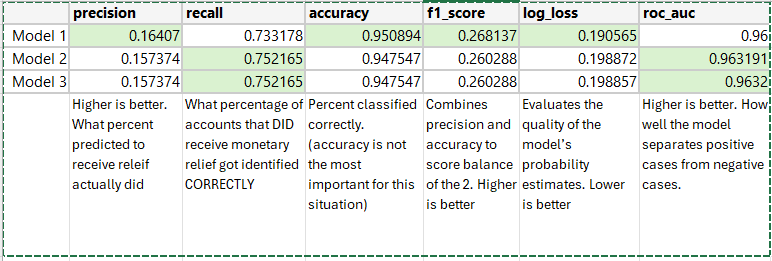